In [1]:
import os

os.environ["PROJ_LIB"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["PROJ_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/proj"
os.environ["GDAL_DATA"] = "/home/abernard/miniconda3/envs/geo_clean/share/gdal"

In [2]:
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rio
import pandas as pd

In [3]:
from pyproj import CRS

print(CRS.from_epsg(2154))

EPSG:2154


In [4]:
gdf = gpd.read_file("../data/RNN_limite_poly_l93.shp")

gdf = gdf.set_crs("EPSG:2154")

gdf = gdf.to_crs("EPSG:4326")


gdf2 = gpd.read_file("../data/limite_RI_wgs84.shp")
gdf2 = gdf2.set_crs("EPSG:4326")

/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: organizePolygons() received an unexpected geometry.  Either a polygon with interior rings, or a polygon with less than 4 points, or a non-Polygon geometry.  Return arguments as a collection.
  return ogr_read(
/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/pyogrio/raw.py:200: RuntimeWarning: Geometry of polygon of fid 0 cannot be translated to Simple Geometry. All polygons will be contained in a multipolygon.
  return ogr_read(


In [5]:
#### NET CDF ######

ds_part1 = xr.open_dataset("../data/HLS_IMG/HLSL30.020_30m_2016.nc", decode_coords="all")
ds_part2 = xr.open_dataset("../data/HLS_IMG/HLSL30.020_30m_2017_2021.nc", decode_coords="all")
ds_part3 = xr.open_dataset("../data/HLS_IMG/HLSL30.020_30m_2022_2026.nc",decode_coords="all")

In [6]:
ds = xr.concat([ds_part1, ds_part2, ds_part3], dim="time", join="override")

In [8]:
red = ds["B04"]
nir = ds["B05"]

ndvi = (nir - red) / (nir + red)
ds["NDVI"] = ndvi
ds["NDVI"].attrs = {
    "long_name": "Normalized Difference Vegetation Index"
}

In [9]:
import cftime
date = cftime.DatetimeJulian(2025, 6, 20)

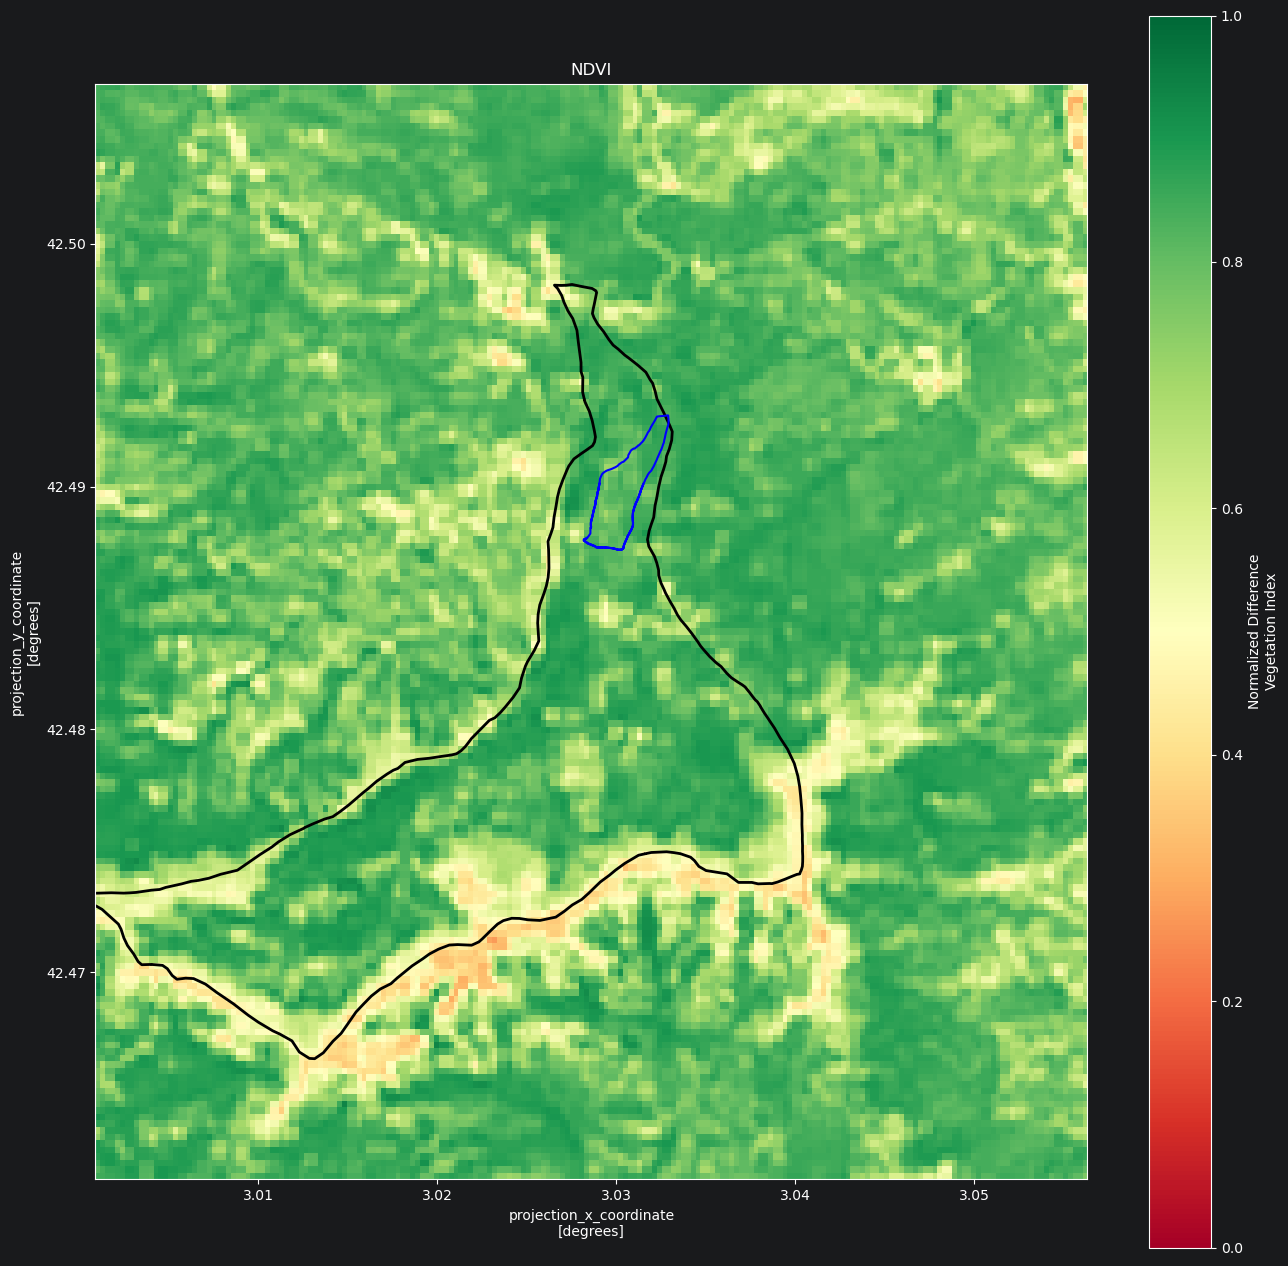

In [10]:
ndvi_day = ds["NDVI"].sel(time=date, method="nearest")

fig, ax= plt.subplots(figsize=(16, 16))

ndvi_day.plot(
    vmin=0,
    vmax=1,
    cmap="RdYlGn"
)

gdf.boundary.plot(
    ax=ax,
    color="black",
    linewidth=2
)

gdf2.boundary.plot(
    ax=ax,
    color="blue"
)

plt.title("NDVI")

plt.show()

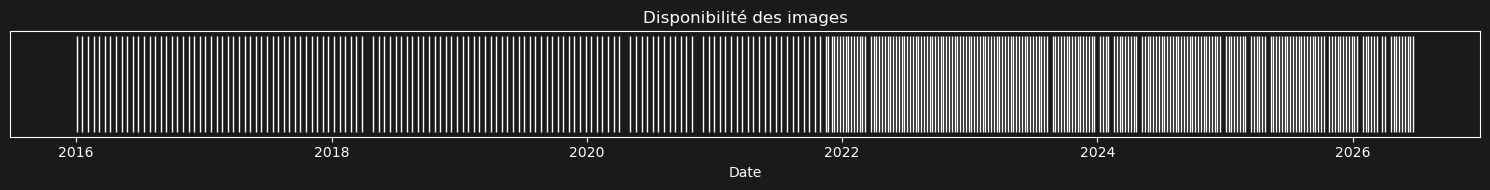

In [11]:
dates = pd.to_datetime([str(t) for t in ds.time.values])

plt.figure(figsize=(15, 2))
plt.vlines(dates, 0, 1, color="white", lw=1)

plt.yticks([])
plt.xlabel("Date")
plt.title("Disponibilité des images")
plt.tight_layout()
plt.show()

In [12]:
ds = ds.rio.write_crs("EPSG:4326")

fmask = ds["Fmask"].astype("uint8")
fmask = fmask.rio.write_crs("EPSG:4326")


# Décodage des bits Fmask
cloud = ((fmask >> 1) & 1) == 1
adjacent = ((fmask >> 2) & 1) == 1
shadow = ((fmask >> 3) & 1) == 1
snow = ((fmask >> 4) & 1) == 1


# Pixels conservés
good = (
    (~cloud)
    &
    (~adjacent)
    &
    (~shadow)
    &
    (~snow)
)

/home/abernard/miniconda3/envs/geo_clean/lib/python3.11/site-packages/xarray/core/duck_array_ops.py:268: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)


In [13]:
ds_clean = ds.where(good)

In [14]:
clipped_ndvi = ds_clean["NDVI"].rio.clip(
    gdf.geometry,
    gdf.crs,
    drop=True
)


clipped_good = good.rio.clip(
    gdf.geometry,
    gdf.crs,
    drop=True
)

In [15]:
dates_valides = []
moyennes_ndvi = []
median_ndvi = []
ratios_good = []


for t in range(clipped_ndvi.sizes["time"]):

    ndvi_t = clipped_ndvi.isel(time=t)

    good_t = clipped_good.isel(time=t)


    # proportion de pixels valides
    ratio_good = good_t.mean().item()


    # garder seulement si >90% de pixels propres
    if ratio_good > 0.90:

        mean_ndvi = ndvi_t.where(good_t).mean().item()

        med_ndvi = ndvi_t.where(good_t).median().item()


        dates_valides.append(
            pd.to_datetime(str(ndvi_t.time.values))
        )

        moyennes_ndvi.append(mean_ndvi)
        median_ndvi.append(med_ndvi)

        ratios_good.append(ratio_good)

In [16]:
df = pd.DataFrame({
    "date": dates_valides,
    "mean_ndvi": moyennes_ndvi,
    "median_ndvi": median_ndvi,
    "ratio_good": ratios_good
})


df = df.sort_values("date")

In [17]:
import cftime

dates_valides_cftime = [  # nouveau xarr avec seulement les dates où -20% de pixels invalides
    cftime.DatetimeJulian(
        d.year,
        d.month,
        d.day
    )
    for d in dates_valides
]

ds_final = ds.sel(time=dates_valides_cftime)

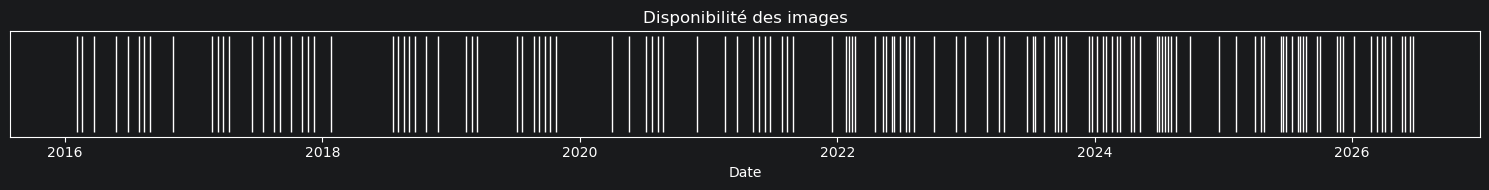

In [18]:

dates = pd.to_datetime([str(t) for t in ds_final.time.values])

plt.figure(figsize=(15, 2))
plt.vlines(dates, 0, 1, color="white", lw=1)

plt.yticks([])
plt.xlabel("Date")
plt.title("Disponibilité des images")
plt.tight_layout()
plt.show()

In [19]:
# Date demandée
date = cftime.DatetimeJulian(2023, 6, 20)

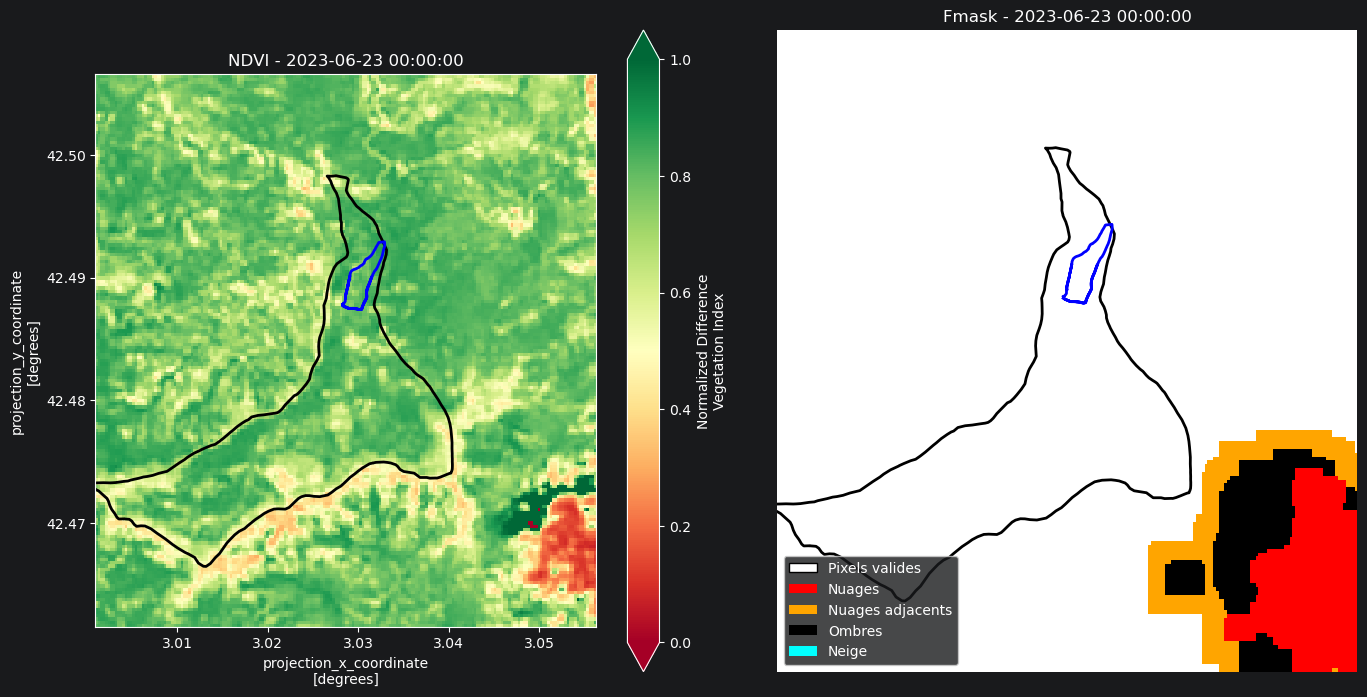

In [20]:
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch


# region Visualisation NDVI + Fmask
# Sélection NDVI avec nearest
ndvi_day = ds_final["NDVI"].sel(
    time=date,
    method="nearest"
)


# Récupération du Fmask correspondant exactement à la même image
fmask_day = ds_final["Fmask"].sel(
    time=ndvi_day.time
).astype("uint8")


# Création des classes Fmask
mask_class = xr.zeros_like(fmask_day)


# 1 = nuages
mask_class = mask_class.where(
    ~(((fmask_day >> 1) & 1) == 1),
    1
)

# 2 = pixels adjacents aux nuages
mask_class = mask_class.where(
    ~(((fmask_day >> 2) & 1) == 1),
    2
)

# 3 = ombres
mask_class = mask_class.where(
    ~(((fmask_day >> 3) & 1) == 1),
    3
)

# 4 = neige
mask_class = mask_class.where(
    ~(((fmask_day >> 4) & 1) == 1),
    4
)


# Colormap des classes
cmap_mask = ListedColormap([
    "white",   # 0 clair
    "red",     # 1 nuage
    "orange",  # 2 adjacent
    "black",   # 3 ombre
    "cyan"     # 4 neige
])


# -------------------------
# Plot
# -------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 7)
)


# NDVI
ndvi_day.plot(
    ax=axes[0],
    vmin=0,
    vmax=1,
    cmap="RdYlGn"
)

axes[0].set_title(
    f"NDVI - {ndvi_day.time.values}"
)


# Fmask
mask_class.plot(
    ax=axes[1],
    cmap=cmap_mask,
    vmin=0,
    vmax=4,
    add_colorbar=False
)

axes[1].set_title(f"Fmask - {ndvi_day.time.values}")

axes[1].axis("off")


# Légende
legend = [
    Patch(facecolor="white", edgecolor="black", label="Pixels valides"),
    Patch(facecolor="red", label="Nuages"),
    Patch(facecolor="orange", label="Nuages adjacents"),
    Patch(facecolor="black", label="Ombres"),
    Patch(facecolor="cyan", label="Neige")
]


axes[1].legend(
    handles=legend,
    loc="lower left"
)


for ax in axes:
    gdf.boundary.plot(
        ax=ax,
        color="black",
        linewidth=2
    )

    gdf2.boundary.plot(
        ax=ax,
        color="blue",
        linewidth=2
    )

plt.tight_layout()
plt.show()

# endregion

In [ ]:
# UTM proj